## Plant Detection Model

In [ ]:
import os

# Function to count total files
def total_files(folder_path):
    return len([f for f in os.listdir(folder_path) if os.path.isfile(os.path.join(folder_path, f))])

# Correct dataset paths (based on your folder structure)
train_files_healthy = "archive/Train/Train/Healthy"
train_files_powdery = "archive/Train/Train/Powdery"
train_files_rust = "archive/Train/Train/Rust"

test_files_healthy = "archive/Test/Test/Healthy"
test_files_powdery = "archive/Test/Test/Powdery"
test_files_rust = "archive/Test/Test/Rust"

valid_files_healthy = "archive/Validation/Validation/Healthy"
valid_files_powdery = "archive/Validation/Validation/Powdery"
valid_files_rust = "archive/Validation/Validation/Rust"

#  Print file counts
print("Number of healthy leaf images in training set:", total_files(train_files_healthy))
print("Number of powdery leaf images in training set:", total_files(train_files_powdery))
print("Number of rusty leaf images in training set:", total_files(train_files_rust))

print("=========================================================")

print("Number of healthy leaf images in test set:", total_files(test_files_healthy))
print("Number of powdery leaf images in test set:", total_files(test_files_powdery))
print("Number of rusty leaf images in test set:", total_files(test_files_rust))

print("=========================================================")

print("Number of healthy leaf images in validation set:", total_files(valid_files_healthy))
print("Number of powdery leaf images in validation set:", total_files(valid_files_powdery))
print("Number of rusty leaf images in validation set:", total_files(valid_files_rust))


Number of healthy leaf images in training set: 458
Number of powdery leaf images in training set: 430
Number of rusty leaf images in training set: 434
Number of healthy leaf images in test set: 50
Number of powdery leaf images in test set: 50
Number of rusty leaf images in test set: 50
Number of healthy leaf images in validation set: 20
Number of powdery leaf images in validation set: 20
Number of rusty leaf images in validation set: 20


In [ ]:

# Show current working directory
print("Current working directory:", os.getcwd())

# List what's inside
print("Contents:", os.listdir())


Current working directory: C:\Users\hp2\Documents\Plant Detection model
Contents: ['.ipynb_checkpoints', 'archive', 'Detection of plants.ipynb', 'plant_disease_model.h5']


In [ ]:
print(os.listdir(r'archive'))

['Test', 'Train', 'Validation']


In [ ]:
# Step 1: Check inside Test
print(os.listdir(r'archive\Test'))

['Test']


In [ ]:
print(os.listdir(r'archive\Test\Test'))


['Healthy', 'Powdery', 'Rust']


In [ ]:
# Show all folders step by step
print("Inside archive:", os.listdir('archive'))
print("Inside archive/Test:", os.listdir('archive/Test'))
print("Inside archive/Test/Test:", os.listdir('archive/Test/Test'))

Inside archive: ['Test', 'Train', 'Validation']
Inside archive/Test: ['Test']
Inside archive/Test/Test: ['Healthy', 'Powdery', 'Rust']


In [ ]:
print(os.listdir(r'archive\Test\Test\Healthy')[:5])


['8ddaa5a5caa5caa8.jpg', '8ddaac1bd6c8cd0a.jpg', '8ddd5ec1c0de38c4.jpg', '8def3f60308ab41b.jpg', '8def4d91382175c3.jpg']


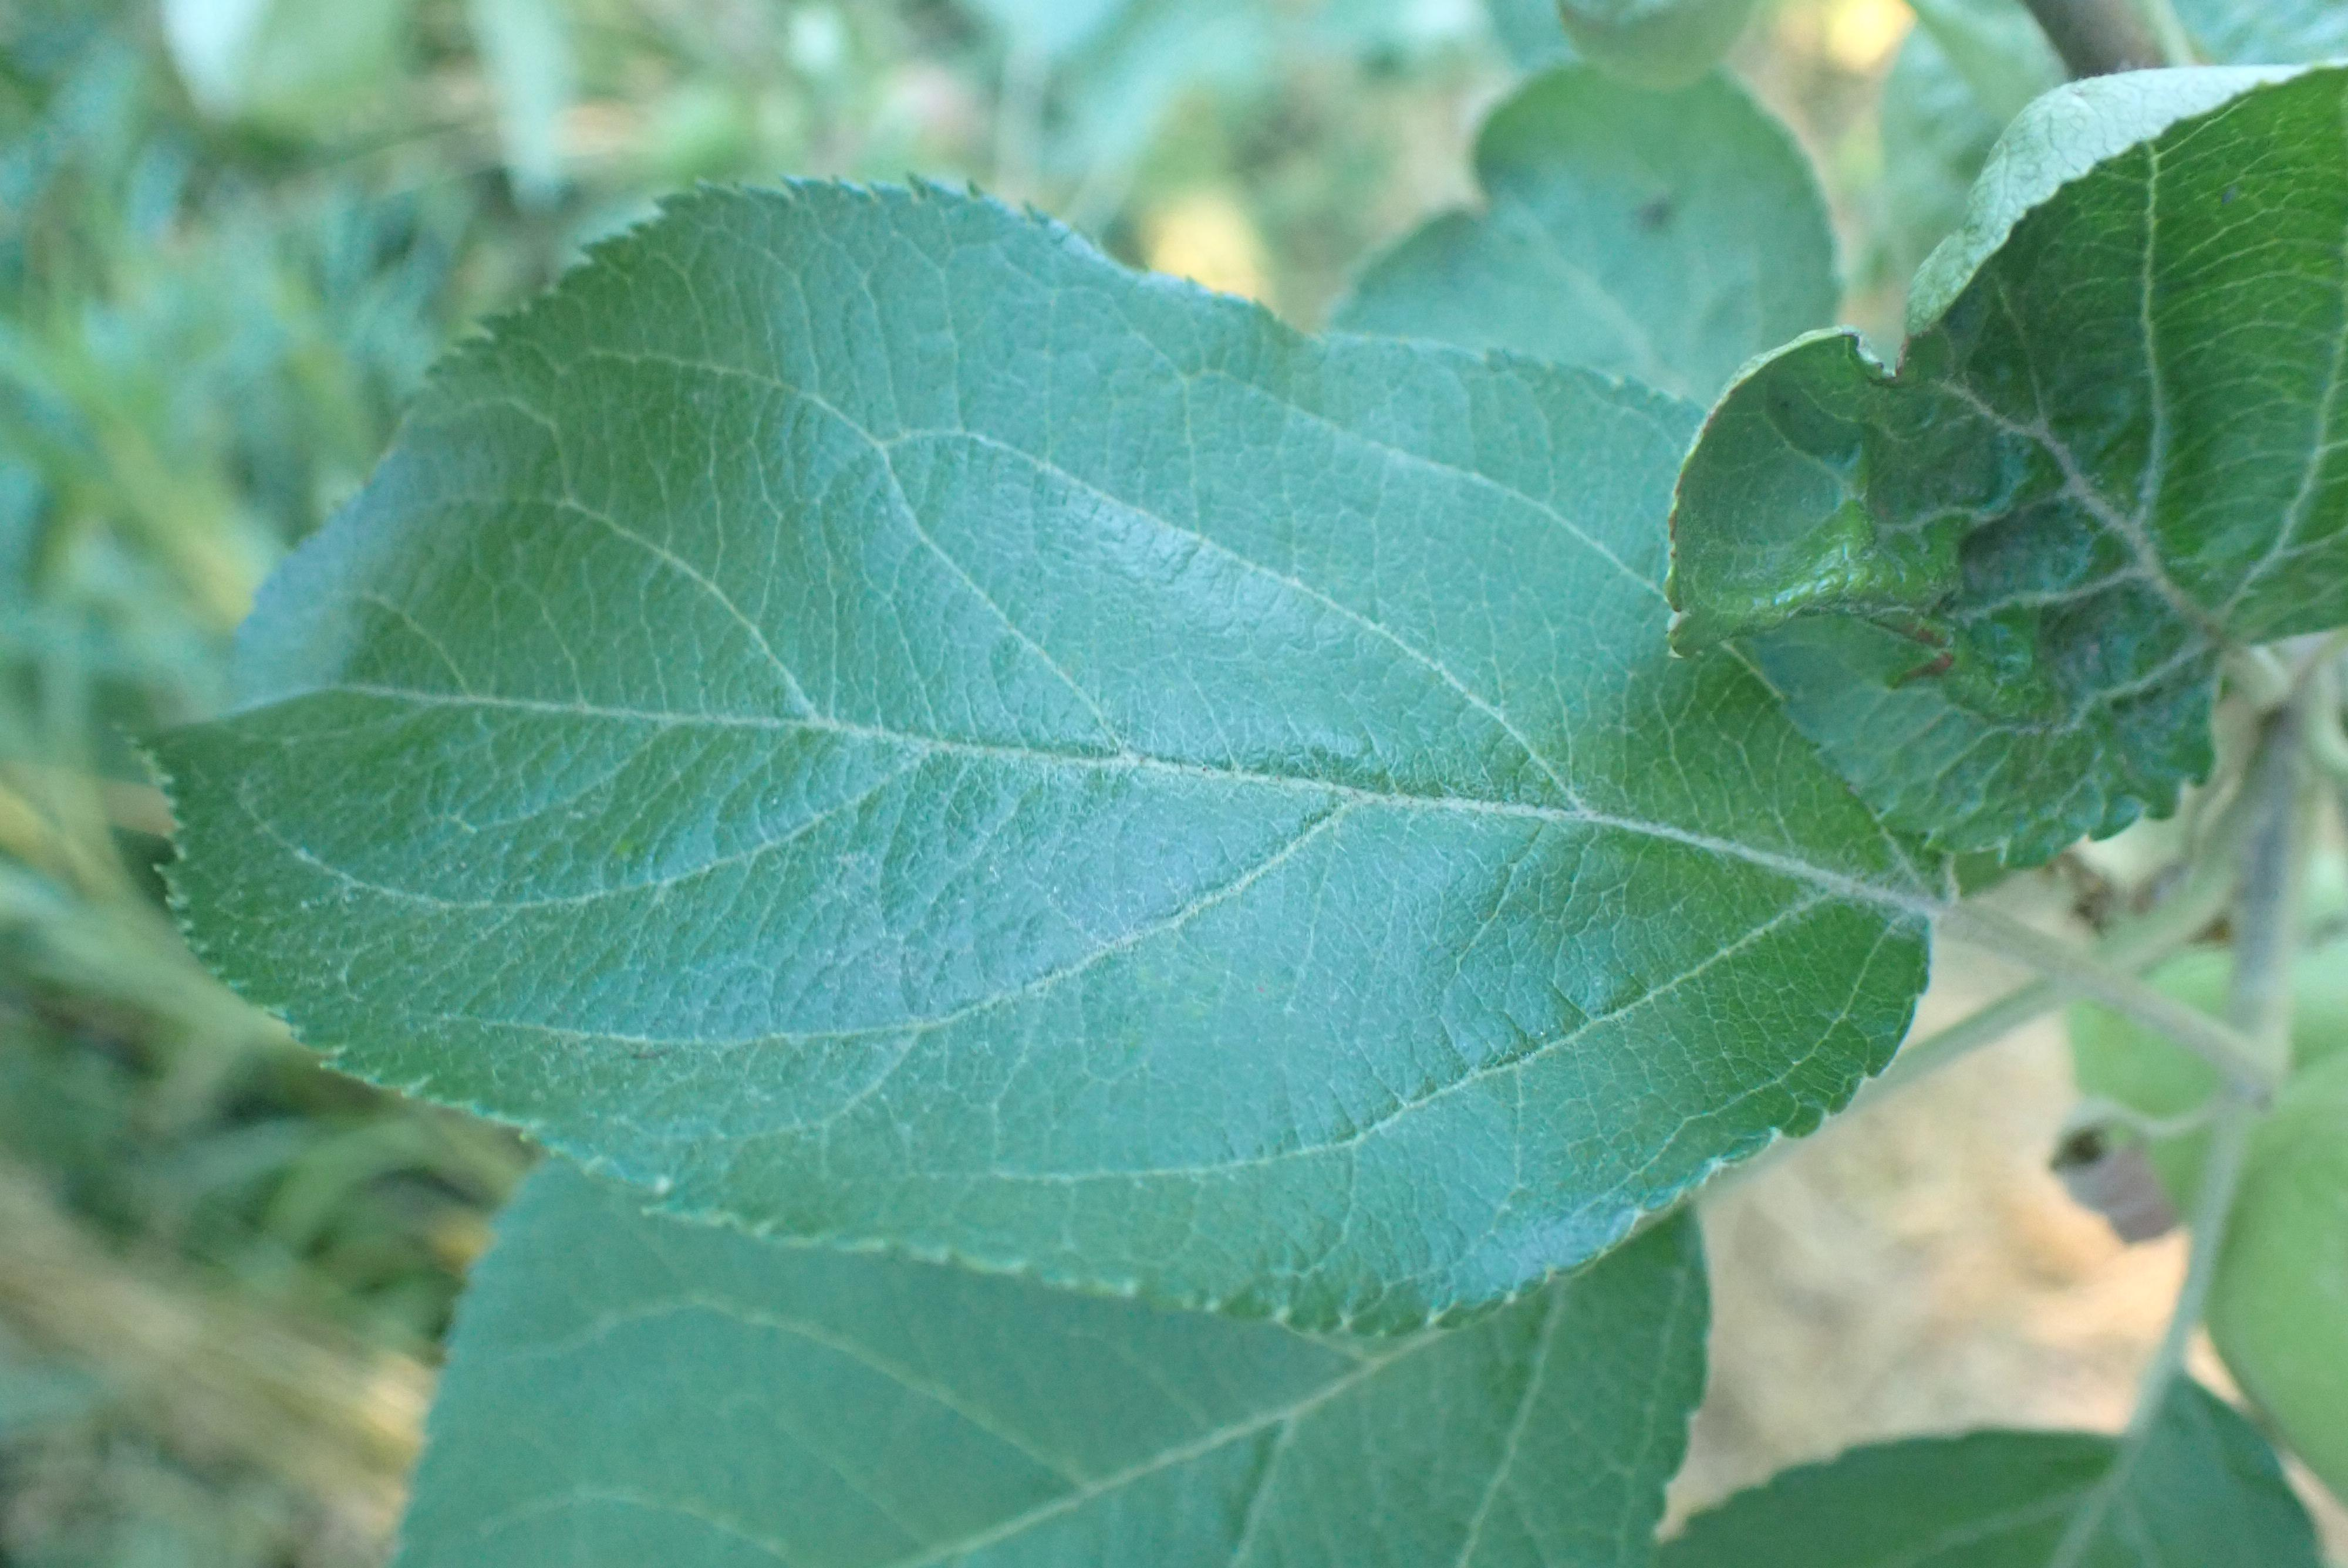

In [2]:
from IPython.display import Image, display

image_path = r'archive\Test\Test\Healthy\8ddaa5a5caa5caa8.jpg'
display(Image(filename=image_path, width=500))

In [3]:
import os
print(os.listdir(r'archive\Train\Train\Rust')[:5])

['807947b90eb77856.jpg', '80933fcc6a673636.jpg', '80f09587dfc7988e.jpg', '8161733dfc3c1c65.jpg', '81a063b69c99ed9e.jpg']


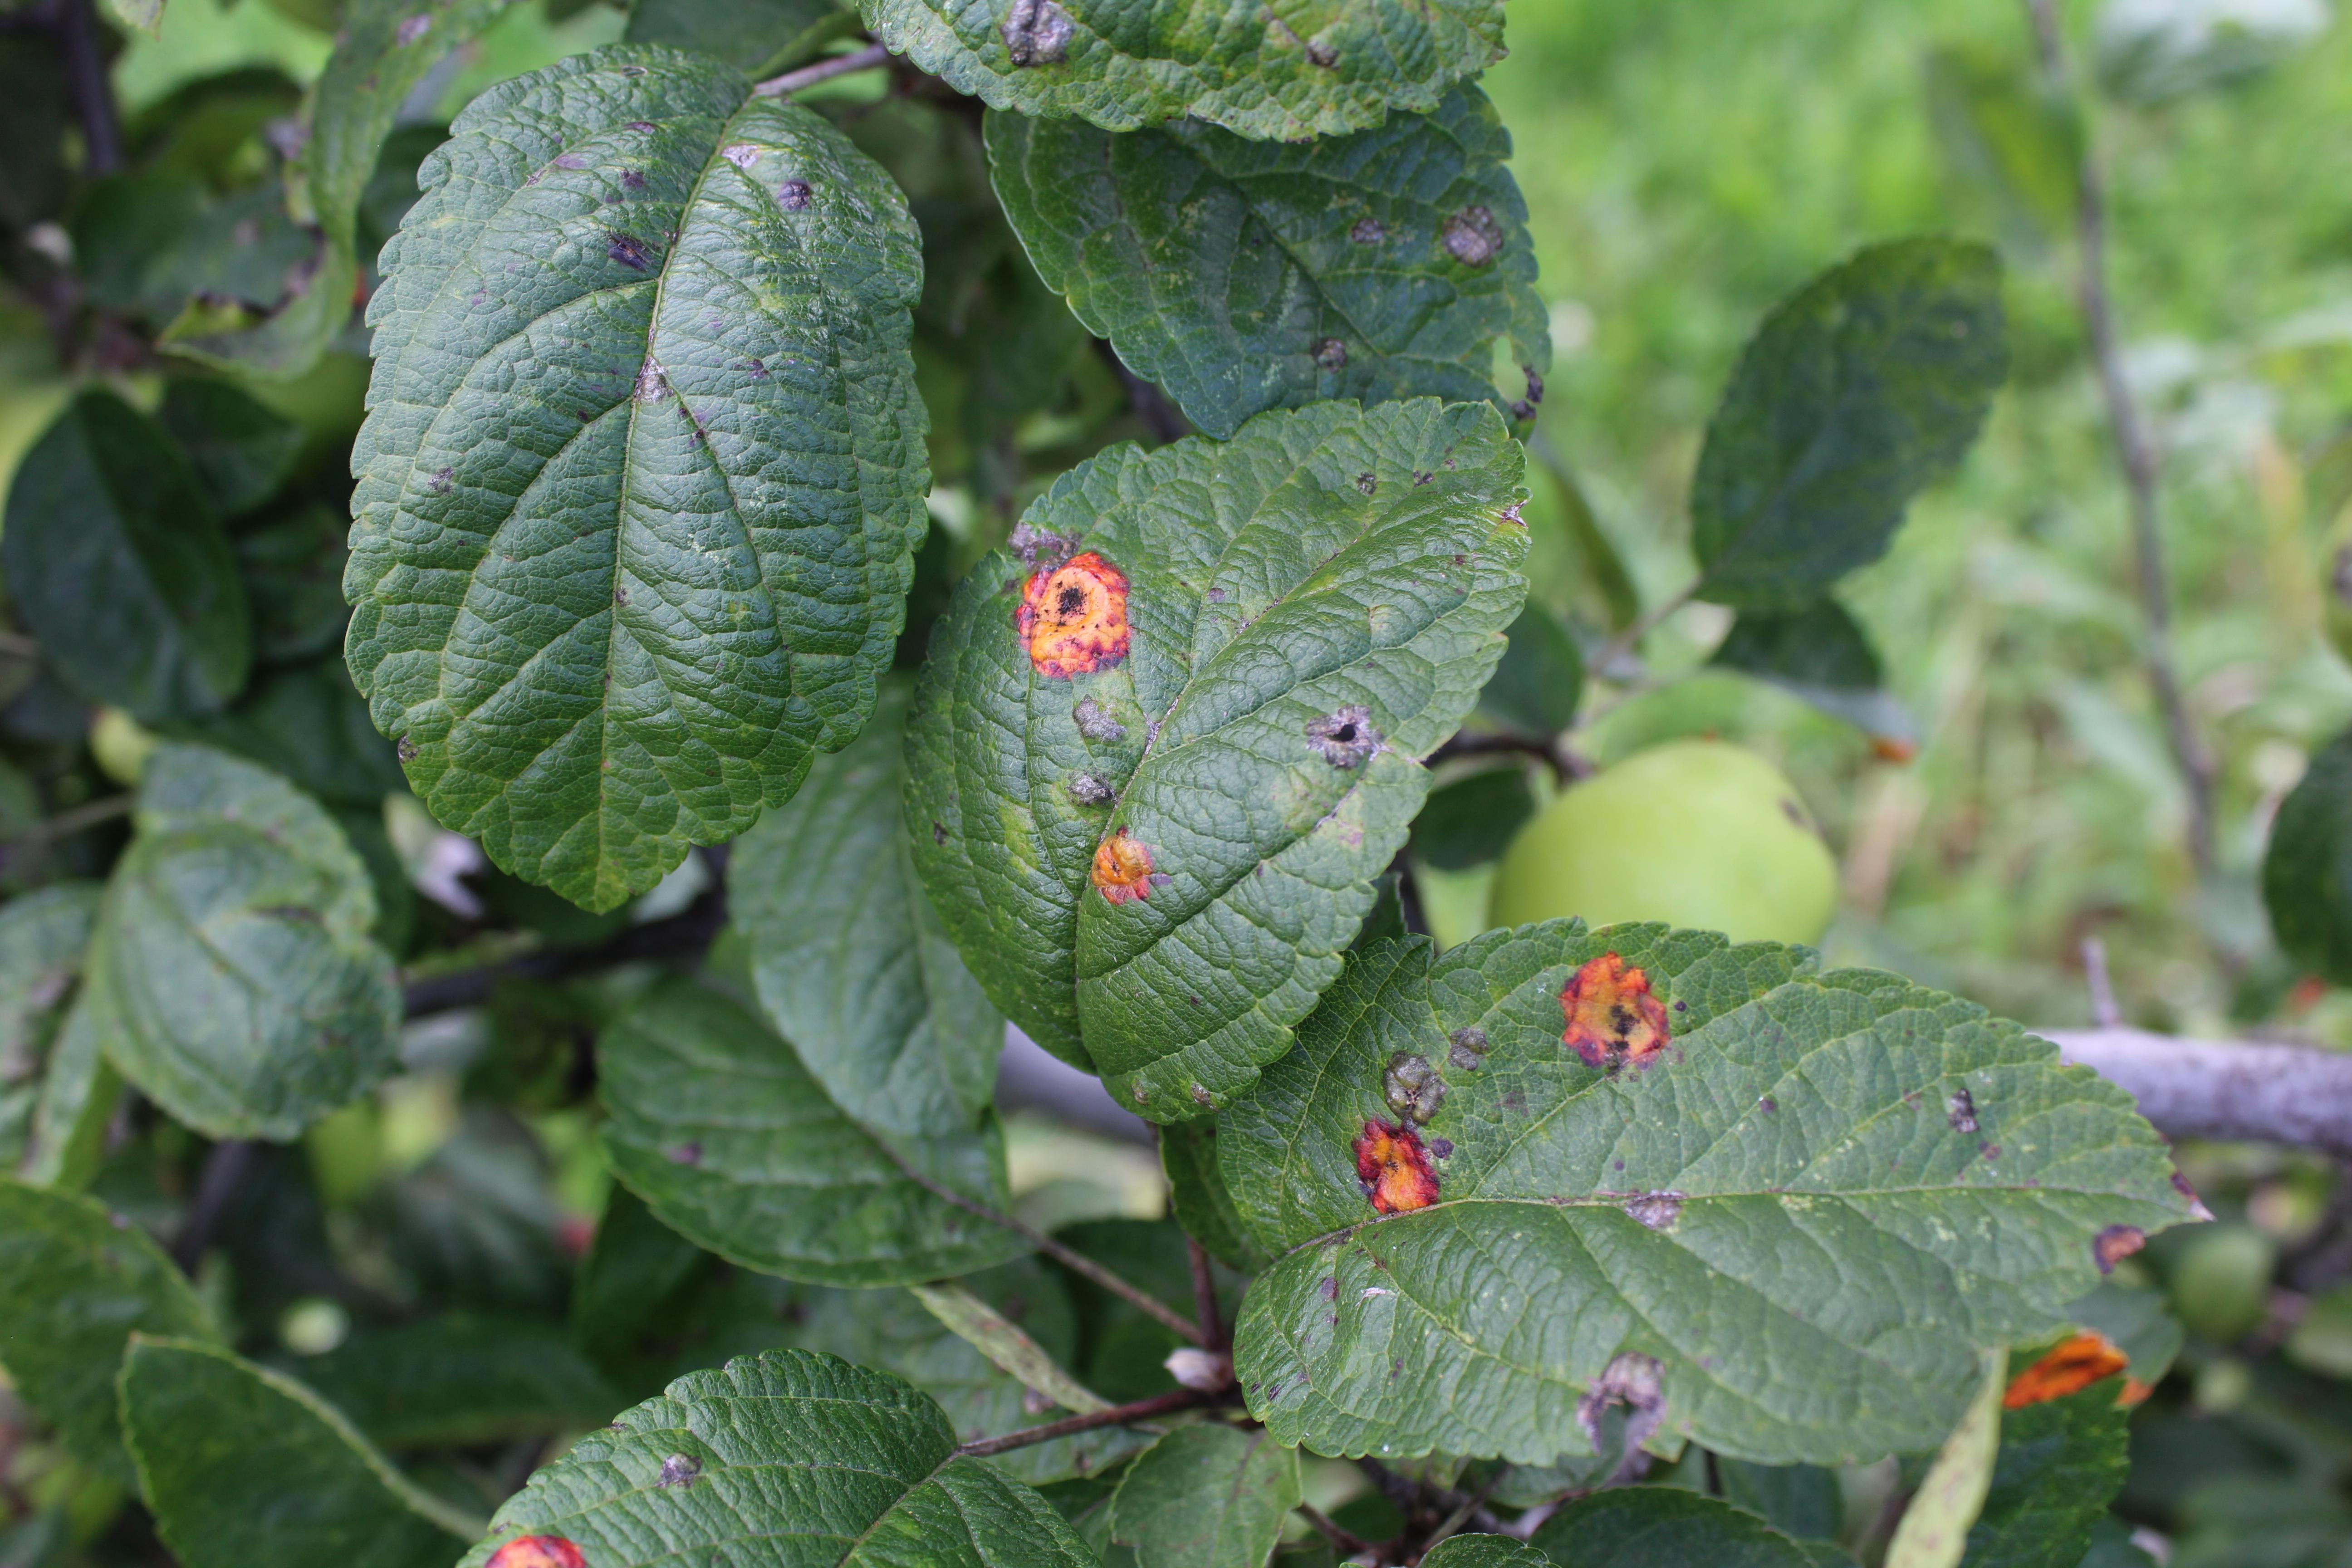

In [4]:
image_path = r'archive\Train\Train\Rust\81a063b69c99ed9e.jpg'
display(Image(filename=image_path, width=500))

In [5]:
print(os.listdir(r'archive\Train\Train\powdery')[:5])

['802f7439ec1ef0cd.jpg', '806d7d0df8cae3c2.jpg', '81352f0c4c5efa9b.jpg', '8192743f44f1d9ad.jpg', '820a7abd7594fc45.jpg']


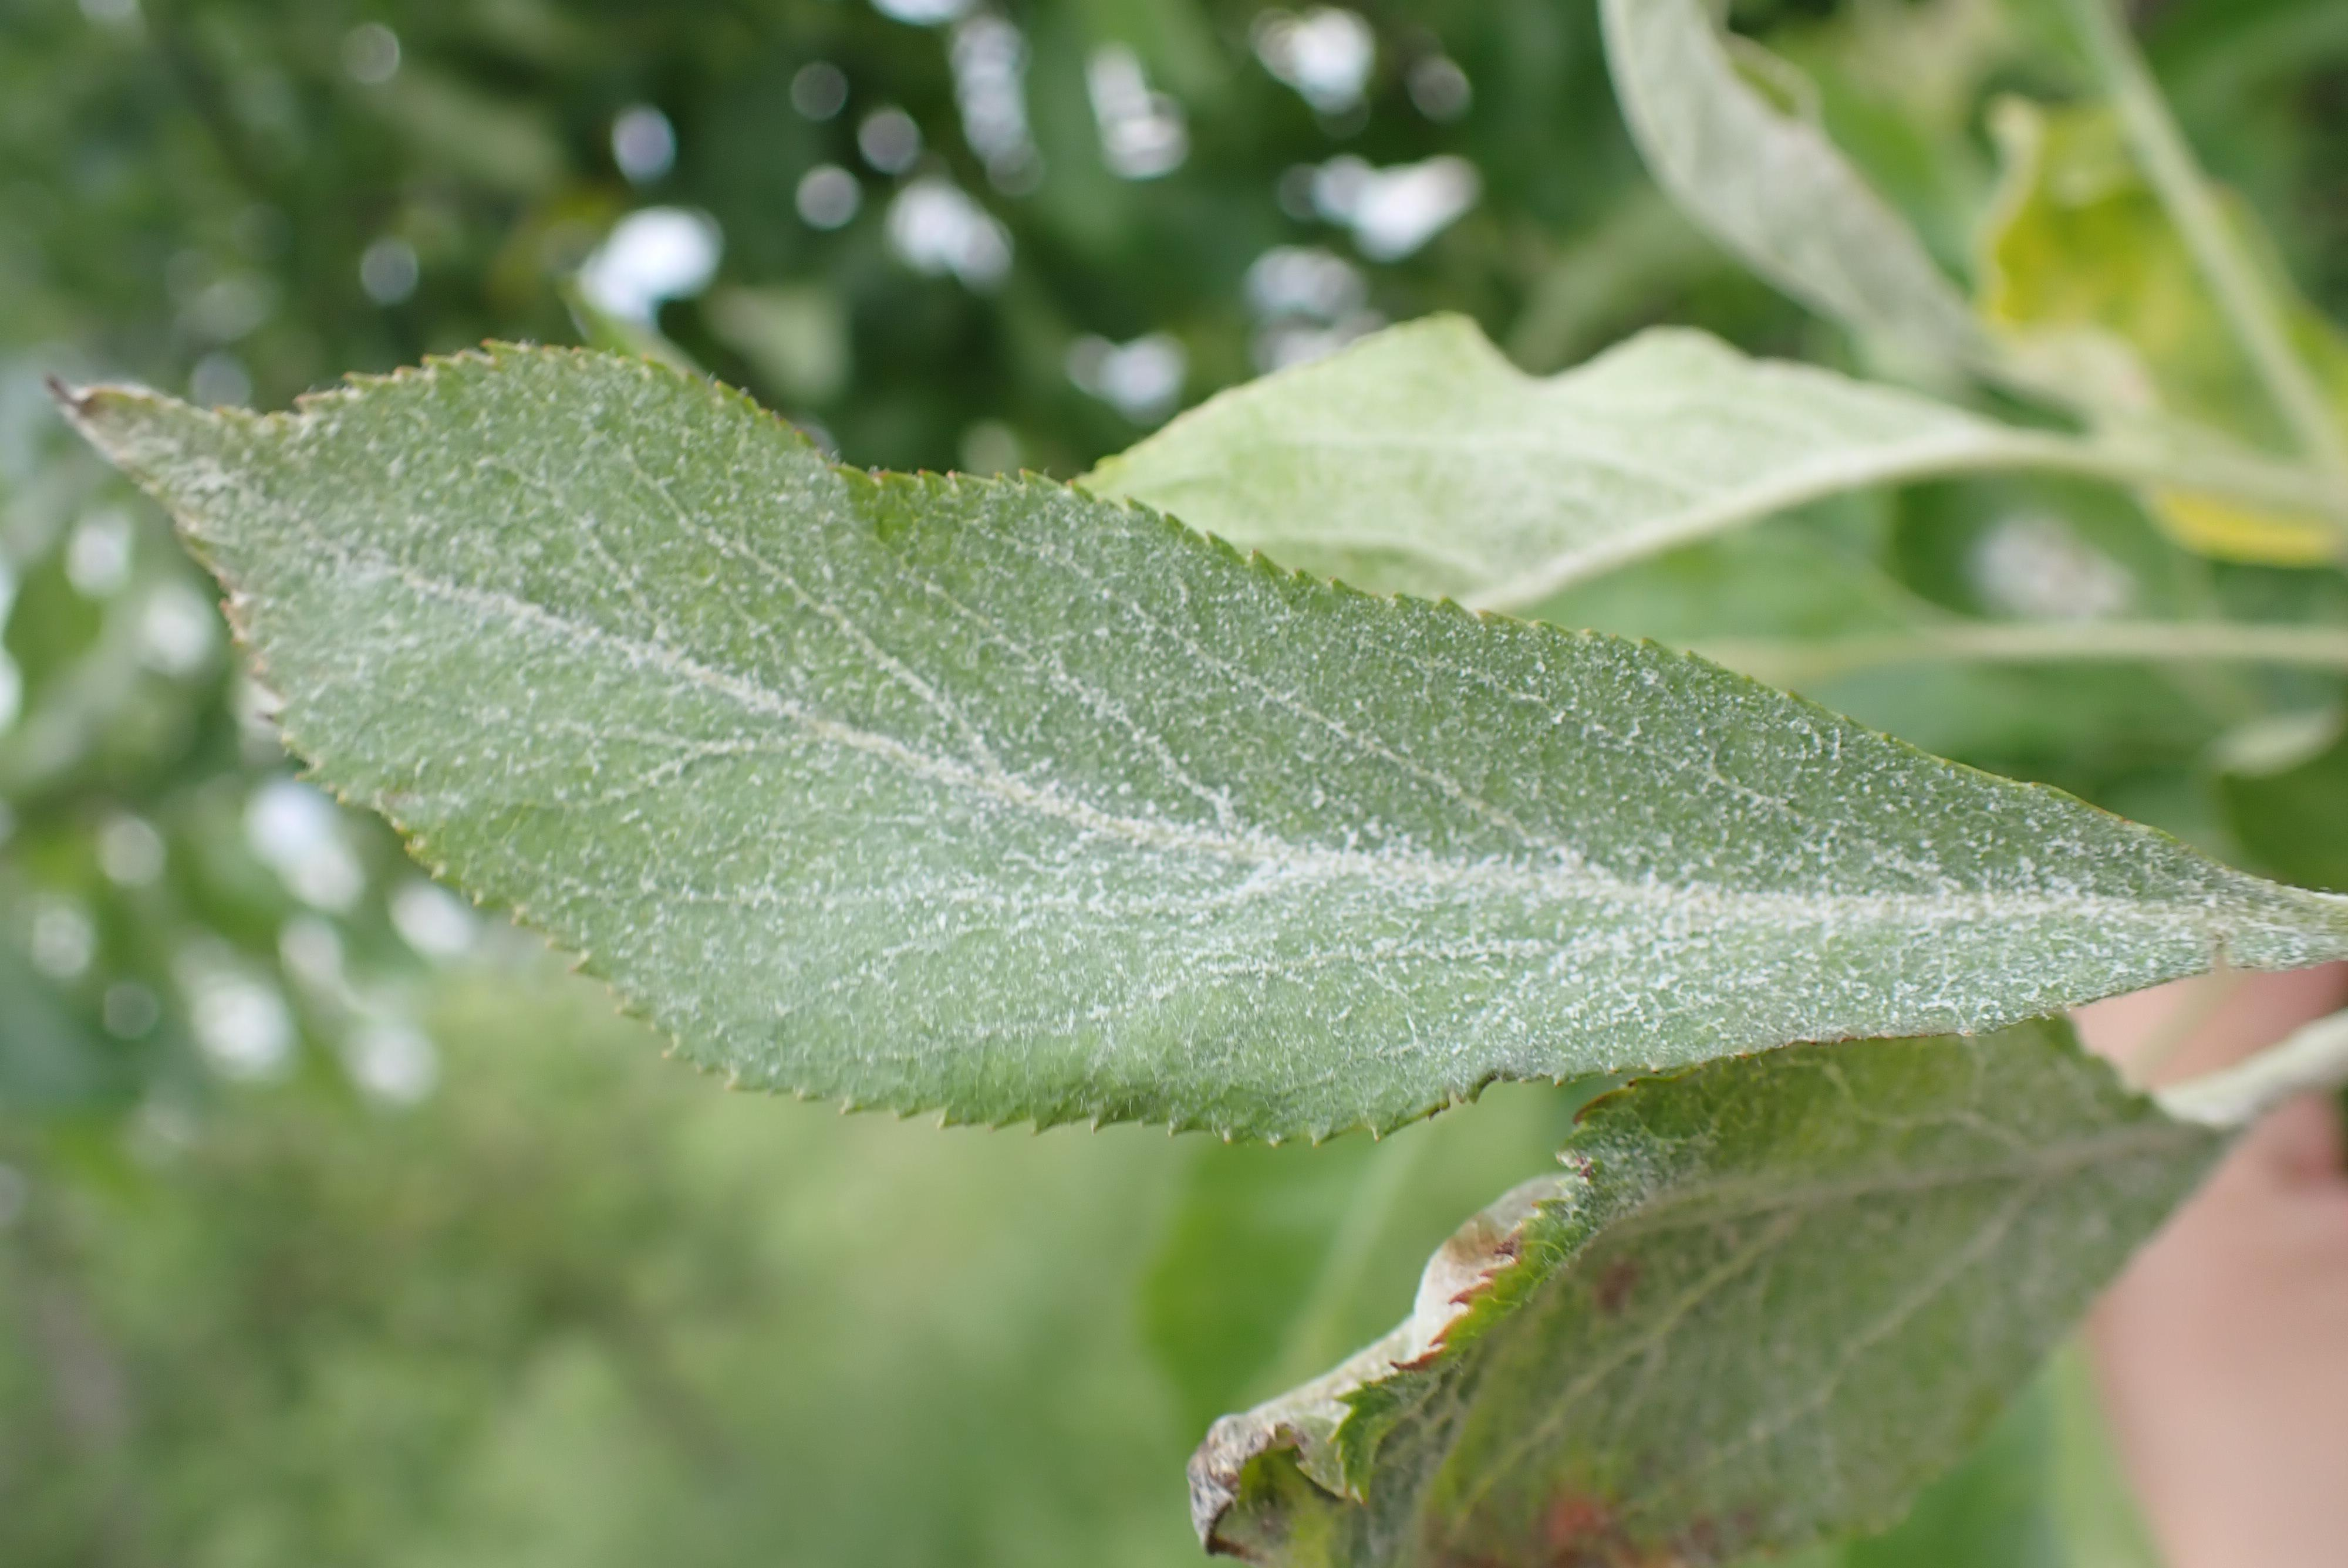

In [6]:
image_path = r'archive\Train\Train\powdery\81352f0c4c5efa9b.jpg'
display(Image(filename=image_path, width=500))

In [1]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define training data generator
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Define validation data generator
test_datagen = ImageDataGenerator(rescale=1./255)

In [2]:
# Training generator
train_generator = train_datagen.flow_from_directory(
    'archive/Train/Train',
    target_size=(225, 225),
    batch_size=32,
    class_mode='categorical'
)

# Validation generator
validation_generator = test_datagen.flow_from_directory(
    'archive/Validation/Validation',
    target_size=(225, 225),
    batch_size=32,
    class_mode='categorical'
)

Found 1322 images belonging to 3 classes.
Found 60 images belonging to 3 classes.


In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Input(shape=(225, 225, 3)),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(3, activation='softmax')  # assuming 3 classes
])

In [10]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)
print("Num GPUs available:", len(tf.config.list_physical_devices('GPU')))

TensorFlow version: 2.20.0
Num GPUs available: 0


In [11]:
import tensorflow as tf
tf.config.run_functions_eagerly(True)

In [12]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',  # for multi-class classification
    metrics=['accuracy']
)

In [44]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [45]:
history = model.fit(
    train_generator,
    steps_per_epoch=len(train_generator),
    epochs=20,
    validation_data=validation_generator,
    validation_steps=len(validation_generator)
)


Epoch 1/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 528s 13s/step - accuracy: 0.8139 - loss: 0.5172 - val_accuracy: 0.8000 - val_loss: 0.4780
Epoch 2/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 688s 16s/step - accuracy: 0.8669 - loss: 0.3959 - val_accuracy: 0.8833 - val_loss: 0.4625
Epoch 3/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 603s 14s/step - accuracy: 0.8669 - loss: 0.3602 - val_accuracy: 0.8167 - val_loss: 0.4977
Epoch 4/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 543s 13s/step - accuracy: 0.8759 - loss: 0.3669 - val_accuracy: 0.8167 - val_loss: 0.4544
Epoch 5/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 631s 15s/step - accuracy: 0.8752 - loss: 0.3612 - val_accuracy: 0.8833 - val_loss: 0.4817
Epoch 6/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 730s 17s/step - accuracy: 0.8812 - loss: 0.3501 - val_accuracy: 0.7667 - val_loss: 0.7275
Epoch 7/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 492s 12s/step - accuracy: 0.8941 - loss: 0.3275 - val_accuracy: 0.8500 - val_loss: 0.4869
Epoch 8/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 501s 12s/step - accuracy: 0.8880 - loss: 0.3307 - val_accuracy: 0.

In [46]:
model.save("model.h5")

In [47]:
#instead of retraining
from tensorflow.keras.models import load_model
model = load_model("model.h5")
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 223, 223, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 186624)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │      23,888,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 3)                   │             387 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 23,907,781 (91.20 MB)

 Trainable params: 23,907,779 (91.20 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

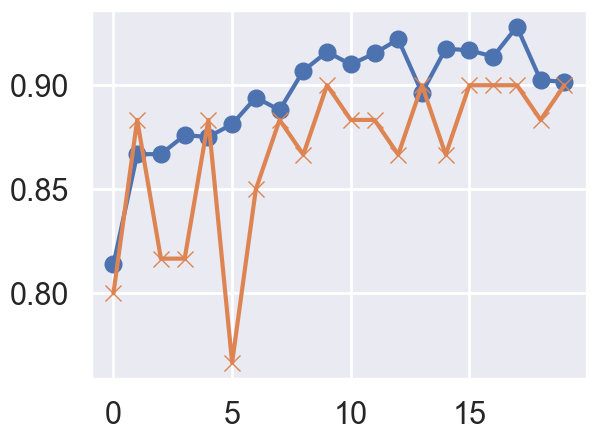

In [48]:
from matplotlib import pyplot as plt
import pickle

# Save history
with open('history.pkl', 'wb') as f:
    pickle.dump(history.history, f)

# Load history
with open('history.pkl', 'rb') as f:
    history_dict = pickle.load(f)

plt.plot(history_dict['accuracy'], marker='o')
plt.plot(history_dict['val_accuracy'], marker='x')


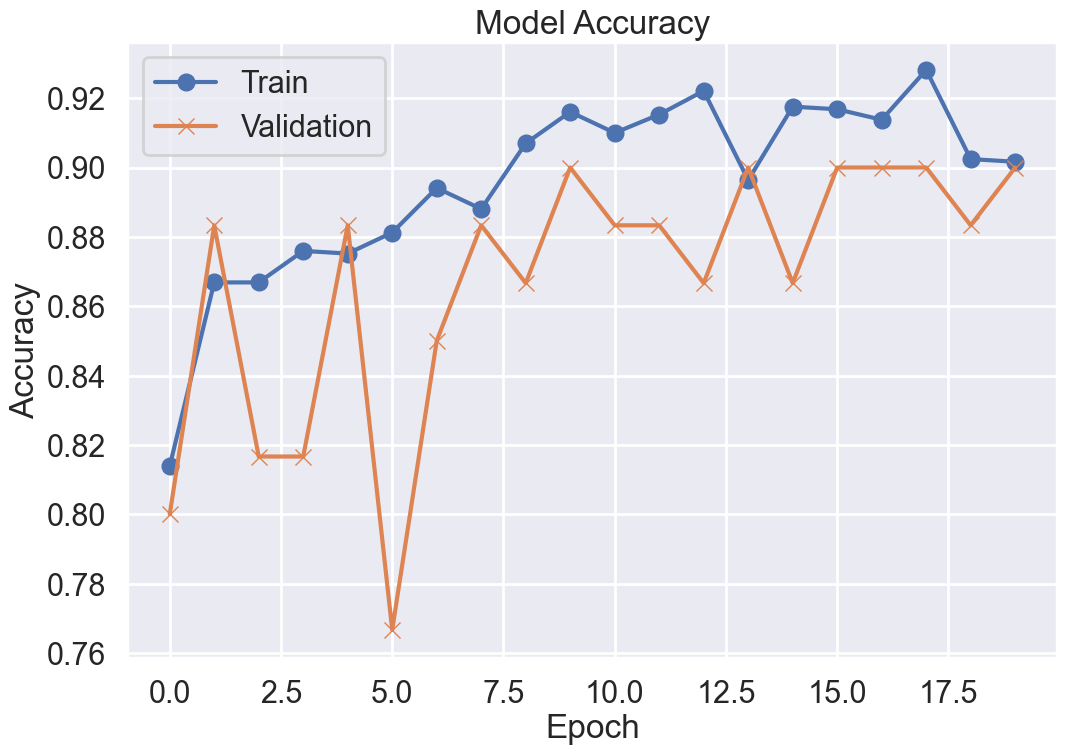

In [49]:
from matplotlib import pyplot as plt
import seaborn as sns

sns.set_theme()
sns.set_context("poster")

plt.figure(figsize=(12, 8))  # slightly smaller figure for normal screens

plt.plot(history.history['accuracy'], marker='o')
plt.plot(history.history['val_accuracy'], marker='x')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.grid(True)
plt.show()

In [50]:
from tensorflow.keras.preprocessing.image import load_img,img_to_array
import numpy as np

def preprocess_image(image_path, target_size=(225,225)):
    img = load_img(image_path, target_size=target_size)
    x = img_to_array(img)
    x = x.astype('float32') / 255.0
    x = np.expand_dims(x,axis=0)
    return x
x = preprocess_image('archive/Test/Test/Rust/82f49a4a7b9585f1.jpg')

In [51]:
predicions = model.predict(x)
predicions[0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step


array([3.8575678e-04, 9.3527124e-09, 9.9961424e-01], dtype=float32)

In [52]:
labels = train_generator.class_indices
print("Class indices:", labels)

# reverse mapping: {0: 'classA', 1: 'classB', ...}
labels = {v: k for k, v in labels.items()}
print("Reversed mapping:", labels)

Class indices: {'Healthy': 0, 'Powdery': 1, 'Rust': 2}
Reversed mapping: {0: 'Healthy', 1: 'Powdery', 2: 'Rust'}


In [53]:
predictions = model.predict(x)
for i, (cls, prob) in enumerate(zip(labels.values(), predictions[0])):
    print(f"{cls}: {prob*100:.2f}%")

predicted_label = labels[np.argmax(predictions)]
print("Predicted label:", predicted_label)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Healthy: 0.04%
Powdery: 0.00%
Rust: 99.96%
Predicted label: Rust


In [54]:
predicted_label = labels[np.argmax(predicions)]
print(predicted_label)

Rust
